# Predicting Bestseller Books Using Logistic Regression From Scratch

## Introduction

Book publishers continuously seek ways to identify books that are likely to become commercially successful. Being able to predict bestseller status can assist publishers in making informed decisions regarding marketing, inventory planning and investment strategies.

The Goodreads Books dataset was selected for this analysis because it contains information relating to book popularity, ratings, reviews and publication details. Since the dataset does not contain a dedicated bestseller indicator, bestseller status will be approximated using book popularity measured through ratings count.

The objective of this project is to develop a Logistic Regression model from scratch capable of classifying books as either bestsellers or non-bestsellers. The project follows a structured machine learning workflow consisting of data preparation, exploratory analysis, feature selection, model development, evaluation and model improvement.

## Project Plan

This project will follow the following analytical workflow:

1. Data Preparation
   - Load and inspect the dataset
   - Clean and transform relevant variables
   - Create the target variable

2. Exploratory Data Analysis
   - Understand feature distributions
   - Investigate relationships between variables

3. Feature Selection and Data Preparation
   - Select relevant predictors
   - Avoid data leakage
   - Split and scale the data

4. Logistic Regression Development
   - Implement Logistic Regression from scratch using NumPy

5. Model Evaluation
   - Assess model performance using standard classification metrics

6. Model Improvement
   - Retrain the model using alternative hyperparameters
   - Compare performance against the baseline model

7. Conclusion
   - Summarise findings, limitations and future recommendations

## Data Preparation

The dataset is loaded and cleaned before analysis. Publication dates are converted into a suitable format, publication years are extracted and a book age variable is created. Bestseller status is approximated using the median ratings count to create a balanced binary target variable.

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load dataset

df = pd.read_csv(
    r"C:\Users\Temba\OneDrive - Badger Holdings\Documents\books.csv",
    engine="python",
    on_bad_lines="skip"
)

# Clean column names

df.columns = df.columns.str.strip()

# Remove duplicates

df = df.drop_duplicates()

# Date handling

df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    errors="coerce"
)

df["publication_year"] = (
    df["publication_date"]
    .dt.year
)

# Feature engineering

df["book_age"] = (
    pd.Timestamp.now().year
    - df["publication_year"]
)

# Create target variable

threshold = df["ratings_count"].median()

df["bestseller"] = (
    df["ratings_count"] > threshold
).astype(int)

print("Dataset Shape:", df.shape)

print("\nClass Distribution:")
print(df["bestseller"].value_counts())

df.head()

Dataset Shape: (11119, 15)

Class Distribution:
bestseller
0    5560
1    5559
Name: count, dtype: int64


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,publication_year,book_age,bestseller
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,2006-09-16,Scholastic Inc.,2006.0,20.0,1
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,2004-09-01,Scholastic Inc.,2004.0,22.0,1
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,2003-11-01,Scholastic,2003.0,23.0,1
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,2004-05-01,Scholastic Inc.,2004.0,22.0,1
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,2004-09-13,Scholastic,2004.0,22.0,1


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is conducted to gain a deeper understanding of the dataset and identify potential relationships between predictor variables and bestseller status. The analysis focuses on variable distributions, class balance and correlations between numerical features.

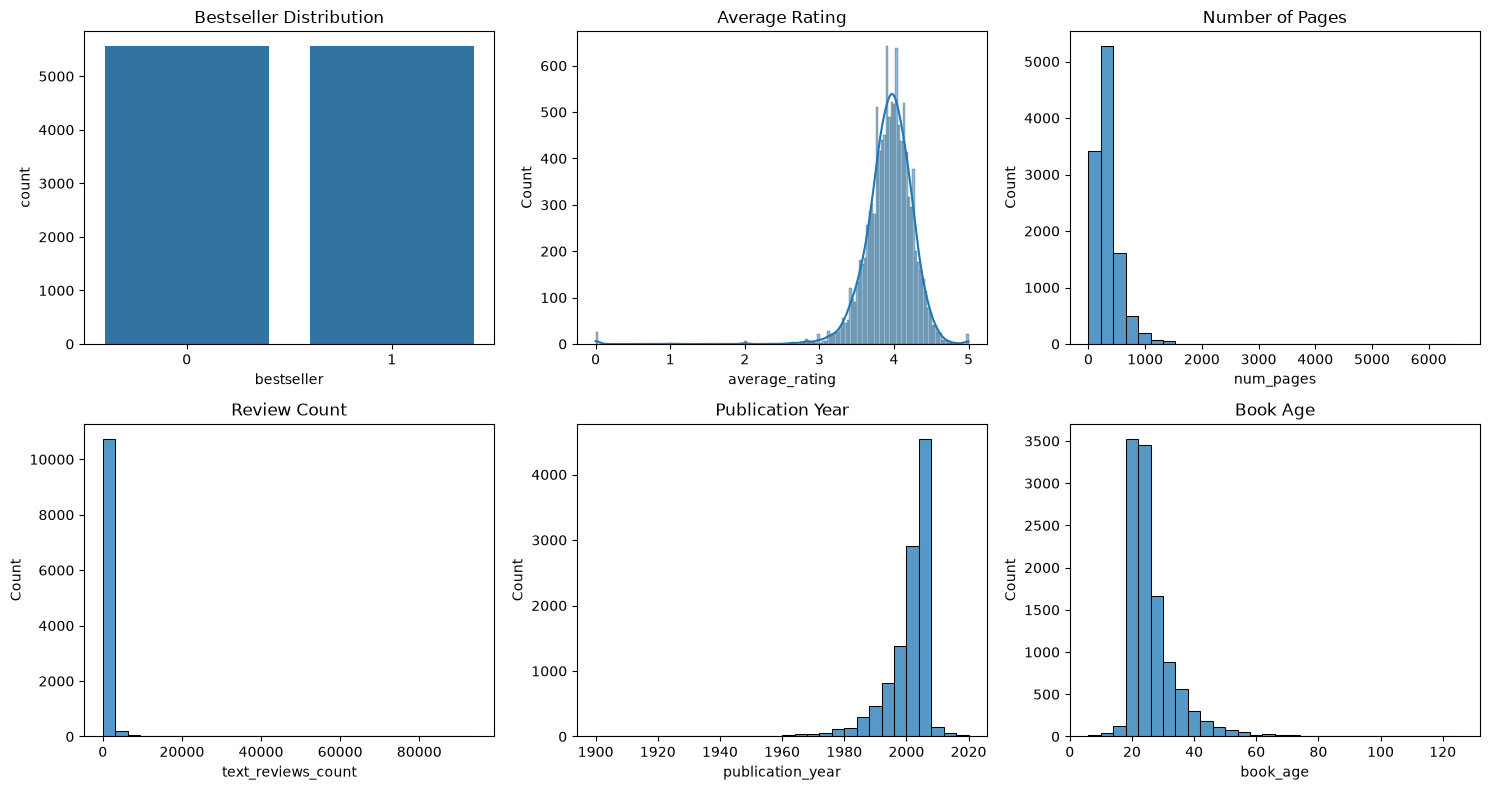

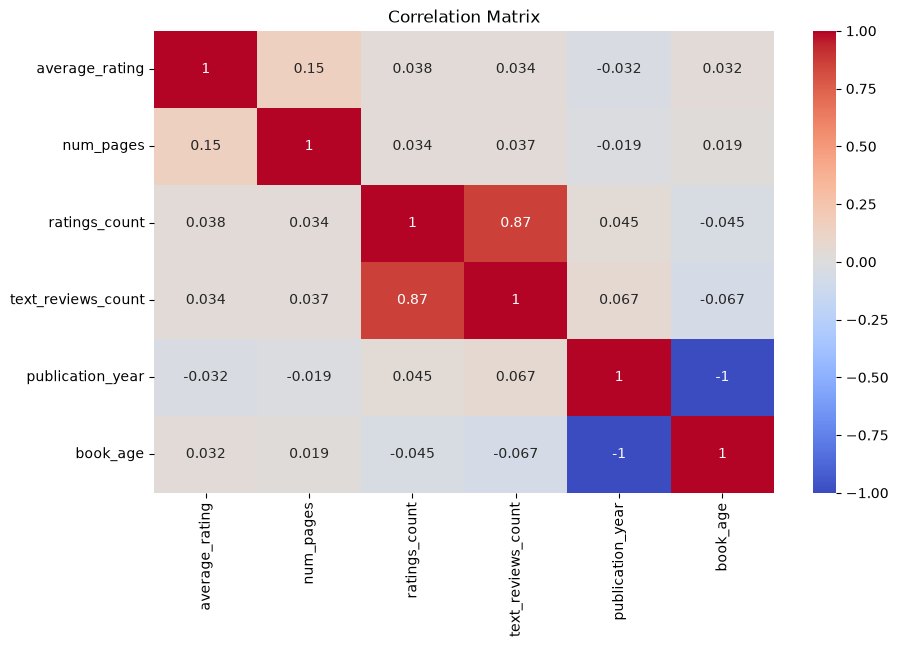

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.countplot(
    data=df,
    x="bestseller",
    ax=axes[0, 0]
)

axes[0, 0].set_title("Bestseller Distribution")

sns.histplot(
    df["average_rating"],
    kde=True,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Average Rating")

sns.histplot(
    df["num_pages"],
    bins=30,
    ax=axes[0, 2]
)

axes[0, 2].set_title("Number of Pages")

sns.histplot(
    df["text_reviews_count"],
    bins=30,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Review Count")

sns.histplot(
    df["publication_year"],
    bins=30,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Publication Year")

sns.histplot(
    df["book_age"],
    bins=30,
    ax=axes[1, 2]
)

axes[1, 2].set_title("Book Age")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

sns.heatmap(
    df[
        [
            "average_rating",
            "num_pages",
            "ratings_count",
            "text_reviews_count",
            "publication_year",
            "book_age"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

### EDA Findings

The target variable is relatively balanced due to the use of the median ratings count as the classification threshold. This is beneficial for model training because it reduces the risk of bias towards a majority class.

Review count appears to be closely related to book popularity, while publication-based variables exhibit weaker relationships. The correlation analysis also highlights the potential influence of book reviews and ratings on bestseller status.

To avoid data leakage in the modelling phase, ratings count will be excluded from the predictor variables because it was used to construct the target variable.

## Feature Selection and Data Preparation for Modelling

Feature selection aims to identify the most relevant predictors while preventing data leakage. Since `ratings_count` was used to construct the target variable, it cannot be included in the model.

The selected features consist of:

- Average Rating
- Number of Pages
- Text Review Count
- Publication Year
- Book Age

The data is then prepared for modelling by handling missing values, ensuring reproducibility, splitting the dataset and applying feature scaling.

In [47]:
model_df = df[
    [
        "average_rating",
        "num_pages",
        "text_reviews_count",
        "publication_year",
        "book_age",
        "bestseller"
    ]
].copy()

# Handle missing values

model_df = model_df.fillna(
    model_df.median(numeric_only=True)
)

# Reproducibility

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Features and target

X = model_df.drop(
    "bestseller",
    axis=1
)

y = model_df["bestseller"]

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Feature scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (8895, 5)
Testing Set Shape: (2224, 5)


## Logistic Regression

Logistic Regression is a supervised learning algorithm commonly used for binary classification problems. Unlike linear regression, Logistic Regression uses the sigmoid function to transform predictions into probabilities ranging between 0 and 1.

For this project, the model will be implemented manually using NumPy rather than Scikit-Learn's built-in implementation. Gradient Descent will be used to optimise the model parameters by minimising prediction error over multiple iterations.

In [58]:
class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):

        y = np.array(y)

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):

            linear_model = (
                np.dot(X, self.weights)
                + self.bias
            )

            predictions = self.sigmoid(
                linear_model
            )

            dw = (
                1 / n_samples
            ) * np.dot(
                X.T,
                (predictions - y)
            )

            db = (
                1 / n_samples
            ) * np.sum(
                predictions - y
            )

            self.weights -= (
                self.learning_rate * dw
            )

            self.bias -= (
                self.learning_rate * db
            )

    def predict_proba(self, X):

        linear_model = (
            np.dot(X, self.weights)
            + self.bias
        )

        return self.sigmoid(
            linear_model
        )

    def predict(self, X):

        probabilities = self.predict_proba(X)

        return np.where(
            probabilities >= 0.5,
            1,
            0
        )

## Baseline Model

A baseline Logistic Regression model is first trained using a learning rate of 0.01 and 1000 training iterations. The model is then evaluated using Accuracy, Precision, Recall, F1-Score and a Confusion Matrix.

These metrics provide insight into how effectively the model distinguishes between bestseller and non-bestseller books.

Baseline Accuracy: 0.6533

Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.71      0.67      1112
           1       0.67      0.60      0.63      1112

    accuracy                           0.65      2224
   macro avg       0.66      0.65      0.65      2224
weighted avg       0.66      0.65      0.65      2224



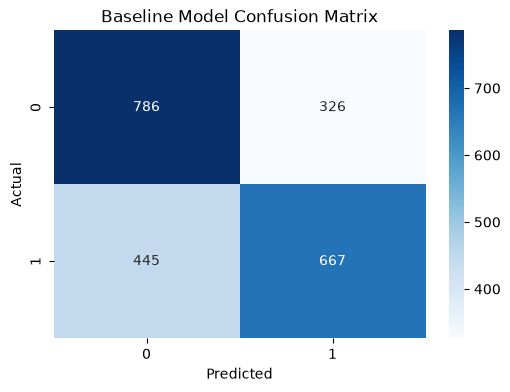

In [59]:
baseline_model = LogisticRegressionScratch(
    learning_rate=0.01,
    epochs=1000
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_predictions = baseline_model.predict(
    X_test
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(
    f"Baseline Accuracy: {baseline_accuracy:.4f}"
)

print(
    "\nClassification Report:\n"
)

print(
    classification_report(
        y_test,
        baseline_predictions
    )
)

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(
        y_test,
        baseline_predictions
    ),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Baseline Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Baseline Model Discussion

The baseline model provides an initial measure of performance and establishes a benchmark against which future improvements can be compared. Although the model is capable of distinguishing between the two classes, further tuning may improve predictive performance.

## Model Improvement

Model performance can often be improved through hyperparameter tuning. To investigate whether the Logistic Regression model can be enhanced, the model will be retrained using a higher learning rate and a greater number of training iterations.

The baseline model used:

- Learning Rate = 0.01
- Epochs = 1000

The improved model will use:

- Learning Rate = 0.05
- Epochs = 2000

The results of both models will then be compared.

Improved Accuracy: 0.7302

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.91      0.77      1112
           1       0.86      0.55      0.67      1112

    accuracy                           0.73      2224
   macro avg       0.77      0.73      0.72      2224
weighted avg       0.77      0.73      0.72      2224



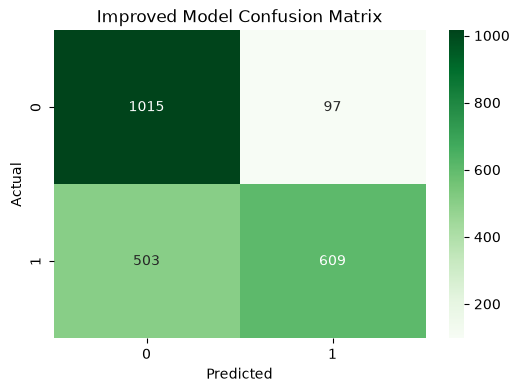

In [60]:
improved_model = LogisticRegressionScratch(
    learning_rate=0.05,
    epochs=2000
)

improved_model.fit(
    X_train,
    y_train
)

improved_predictions = improved_model.predict(
    X_test
)

improved_accuracy = accuracy_score(
    y_test,
    improved_predictions
)

print(
    f"Improved Accuracy: {improved_accuracy:.4f}"
)

print(
    "\nClassification Report:\n"
)

print(
    classification_report(
        y_test,
        improved_predictions
    )
)

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(
        y_test,
        improved_predictions
    ),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Improved Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Training and Testing Gini Comparison

Accuracy alone does not fully measure a classification model's discriminatory power. The Gini coefficient is therefore calculated for both the training and testing datasets to assess model performance and potential overfitting.

A large difference between training and testing Gini may indicate overfitting, while similar values suggest that the model generalises well to unseen data.

In [62]:
from sklearn.metrics import roc_auc_score
import pandas as pd

# Baseline Model

baseline_train_prob = baseline_model.predict_proba(X_train)
baseline_test_prob = baseline_model.predict_proba(X_test)

baseline_train_gini = (
    2 * roc_auc_score(
        y_train,
        baseline_train_prob
    )
) - 1

baseline_test_gini = (
    2 * roc_auc_score(
        y_test,
        baseline_test_prob
    )
) - 1

# Improved Model

improved_train_prob = improved_model.predict_proba(X_train)
improved_test_prob = improved_model.predict_proba(X_test)

improved_train_gini = (
    2 * roc_auc_score(
        y_train,
        improved_train_prob
    )
) - 1

improved_test_gini = (
    2 * roc_auc_score(
        y_test,
        improved_test_prob
    )
) - 1

gini_comparison = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "Accuracy": [
        np.round(baseline_accuracy, 4),
        np.round(improved_accuracy, 4)
    ],
    "Training Gini": [
        np.round(baseline_train_gini, 4),
        np.round(improved_train_gini, 4)
    ],
    "Testing Gini": [
        np.round(baseline_test_gini, 4),
        np.round(improved_test_gini, 4)
    ]
})

gini_comparison

,Model,Accuracy,Training Gini,Testing Gini
0,Baseline,0.6533,0.4115,0.3942
1,Improved,0.7302,0.6625,0.6631


### ROC Curve Analysis

Receiver Operating Characteristic (ROC) curves were generated for both the baseline and improved models.

The Area Under the Curve (AUC) and corresponding Gini coefficients provide insight into each model's ability to discriminate between bestseller and non-bestseller books across all possible classification thresholds.

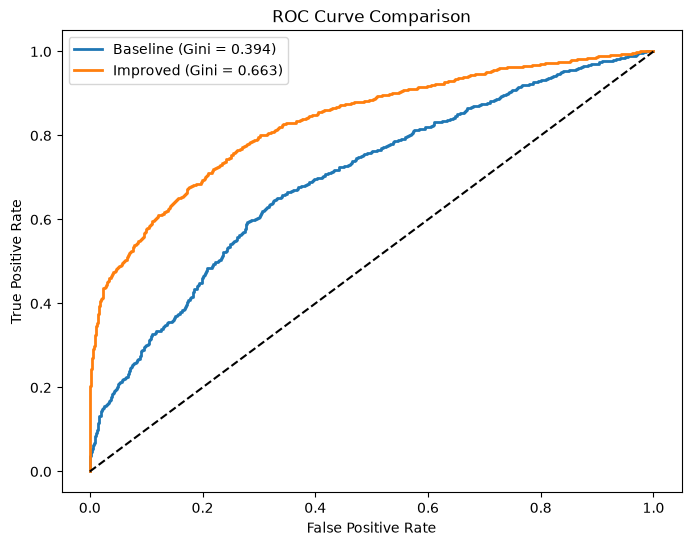

In [63]:
from sklearn.metrics import roc_curve

# Baseline ROC

baseline_fpr, baseline_tpr, _ = roc_curve(
    y_test,
    baseline_test_prob
)

# Improved ROC

improved_fpr, improved_tpr, _ = roc_curve(
    y_test,
    improved_test_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=f"Baseline (Gini = {baseline_test_gini:.3f})",
    linewidth=2
)

plt.plot(
    improved_fpr,
    improved_tpr,
    label=f"Improved (Gini = {improved_test_gini:.3f})",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

### Gini and ROC Analysis

The baseline model achieved a testing Gini coefficient of 0.3942, indicating moderate discriminatory power.

Following retraining, the testing Gini coefficient increased substantially to 0.6631, demonstrating a significant improvement in the model's ability to distinguish between bestseller and non-bestseller books.

The similarity between the training Gini coefficient (0.6625) and testing Gini coefficient (0.6631) suggests that the improved model generalises well to unseen data and shows no significant evidence of overfitting.

The ROC curve further confirms the superior performance of the improved model, as its curve lies consistently above that of the baseline model.